# V768 - Measuring Vision with Psychophysics

## Lab 6 - Discrimination vs. Estimation Part I: 2D Motion

The experiments in previous labs have included ***detection*** and ***discrimination*** tasks, and the stimuli have been <u>static</u> gratings. In the next few labs, we will start using <u>moving</u> stimuli, and we will begin to explore different experimental designs for measuring perception.

In this lab and the next, we will use ***discrimination*** and ***estimation*** tasks to measure **motion** perception. Two commonly used stimuli in motion perception experiments are <u>drifting</u> gratings and <u>**random dot kinematograms**</u>. For this lab, we will measure **speed** perception using dot stimuli. The first task will be a two-interval forced choice (2IFC) speed discrimination task, and the second task will be a rating-based speed estimation task.

### Learning Outcomes

(i.e., what you will be able to do at the end of this lab)

- Design a discrimination experiment.

- Design a rating-based estimation experiment.

- Compare discrimination experiments and rating-based experiments, identifying strengths and weaknesses of each.

### Questions

- Include and write a caption for the LAST figure in Part A, Step 3 (Analyze the data).

- Include and write a caption for the LAST figure in Part B, Step 3 (Analyze the data).

- What are the differences between a drifting grating and a random dot kinematogram? Both stimuli give us the opportunity present visual motion, but they are quite different in appearance. How might that affect the results of an experiment?

- Reflect on your experiences in the speed discrimination and speed estimation experiments in this lab. Do you think that these experiments measure the same thing? Which of these experiments was easier for you as a subject? Why? Which of these experiments is easier to interpret as an experimenter? Why?

## Part A. Speed Discrimination Experiment

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "speed-discrimination", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 140 trials.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [43]:
from pathlib import Path
from statistics import NormalDist
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import psignifit as ps
except ImportError:
    ps = None

rng = np.random.default_rng(2025)


def normcdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.cdf, otypes=[float])(x)


def norminv(p, mu, sigma):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, np.finfo(float).eps, 1 - np.finfo(float).eps)
    sigma = max(float(sigma), np.finfo(float).eps)
    dist = NormalDist(float(mu), sigma)
    return np.vectorize(dist.inv_cdf, otypes=[float])(p)


def psyfxn(c, x):
    c = np.asarray(c, dtype=float)
    return (normcdf(x, c[0], c[1]) * (1 - c[2] - c[3])) + c[2]


def ipsyfxn(c, p):
    c = np.asarray(c, dtype=float)
    return norminv((np.asarray(p, dtype=float) - c[2]) / (1 - c[2] - c[3]), c[0], c[1])


def fit_psignifit(data, experiment_type="yes/no"):
    if ps is None:
        raise ImportError("psignifit is required for psychometric fitting. Install it with: pip install psignifit")
    try:
        return ps.psignifit(data, experiment_type=experiment_type, sigmoid="norm")
    except TypeError:
        exp_type = "YesNo" if experiment_type.lower() in {"yes/no", "yesno", "yes-no"} else experiment_type
        options = {"expType": exp_type, "sigmoidName": "norm"}
        return ps.psignifit(data, options)


def psignifit_parameter_array(result, fallback_gamma=0.0, fallback_lambda=0.0):
    if hasattr(result, "parameter_estimate"):
        params = result.parameter_estimate
        try:
            mu, sigma = result.standard_parameter_estimate()
        except Exception:
            mu = params.get("threshold", np.nan)
            sigma = params.get("width", np.nan)
        return np.array([
            mu,
            sigma,
            params.get("gamma", fallback_gamma),
            params.get("lambda", fallback_lambda),
        ], dtype=float)

    if isinstance(result, dict):
        fit = np.asarray(result["Fit"], dtype=float)
        # psignifit 4 order is commonly [threshold, width, lambda, gamma, eta].
        return np.array([
            fit[0],
            fit[1],
            fit[3] if fit.size > 3 else fallback_gamma,
            fit[2] if fit.size > 2 else fallback_lambda,
        ], dtype=float)

    raise TypeError("Could not read fitted parameters from this psignifit result object.")


def psignifit_predict(result, x, params=None):
    x = np.asarray(x, dtype=float)
    if hasattr(result, "proportion_correct"):
        return np.asarray(result.proportion_correct(x), dtype=float)
    if params is None:
        params = psignifit_parameter_array(result)
    return psyfxn(params, x)


def find_participant_files(data_dir, participant_id):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(
            "PsychoPy data folder not found. Try changing your current Python "
            "folder to the folder containing this notebook."
        )
    file_paths = sorted(path for path in data_dir.glob(f"{participant_id}*.csv") if path.name.startswith(participant_id))
    if not file_paths:
        raise FileNotFoundError("No files found.")
    file_info = pd.DataFrame({
        "name": [path.name for path in file_paths],
        "folder": [str(path.parent) for path in file_paths],
        "path": file_paths,
    })
    print("data files found:")
    for name in file_info["name"]:
        print(f'    "{name}"')
    return file_info


def load_psychopy_csvs(file_info, remove_instruction_rows=True):
    frames = []
    for path in file_info["path"]:
        this_data = pd.read_csv(path)
        if remove_instruction_rows:
            if "thisN" in this_data.columns:
                this_data = this_data[this_data["thisN"].notna()]
            elif "trials.thisN" in this_data.columns:
                this_data = this_data[this_data["trials.thisN"].notna()]
            else:
                this_data = this_data.iloc[1:]
        frames.append(this_data.reset_index(drop=True))
    data = pd.concat(frames, ignore_index=True)
    data = data.drop(columns=["notes", "begin_experiment.started", "begin_experiment.stopped"], errors="ignore")
    return data


def display_fit_table(params, columns=("fit",)):
    return pd.DataFrame(
        np.asarray(params).reshape(4, -1),
        index=["mu", "sigma", "gamma", "lambda"],
        columns=list(columns),
    )
participant_id = "demo"

# check current working directory and find files
discrim_file_info = find_participant_files(Path("speed-discrimination") / "data", participant_id)
n_files = len(discrim_file_info)


data files found:
    "demo_speed-discrimination_2025-02-14_20h15.56.467.csv"


**Confirm that all of your data files are listed above.** There should be one file.

#### Load and merge data tables


In [44]:
# load data and stack it into one table
discrim_data = load_psychopy_csvs(discrim_file_info)

# display data table size
n_trials = len(discrim_data)
print(f"number of trials = {n_trials}")


number of trials = 70


### Step 3. Analyze the data

For this experiment, the stimulus was a random dot kinematogram. Half of the trials showed motion to the left, and half showed motion to the right.

You performed a **2IFC** speed discrimination task. In the first interval, you saw the <u>**reference**</u> stimulus, and in the second interval, you saw the <u>**test**</u> stimulus. You indicated whether the motion you saw in the second interval was ***faster*** or ***slower*** than the first. In other words, your response indicated whether you thought the test speed was greater than or less than the reference speed. The reference speed remained the same throughout the experiment, while the test speed varied.

For each trial, PsychoPy saved speed1 and speed2. The responses were stored in key_resp_keys as 'up' (faster) or 'down' (slower).


In [45]:
# stash the stimulus speed
stim_speed = discrim_data["speed2"].astype(float)
stim_abs_speed = stim_speed.abs()

# convert the response key to 1 for up/faster and 0 for down/slower
response = discrim_data["key_resp.keys"].astype(str).eq("up")


#### Visualize the response per trial


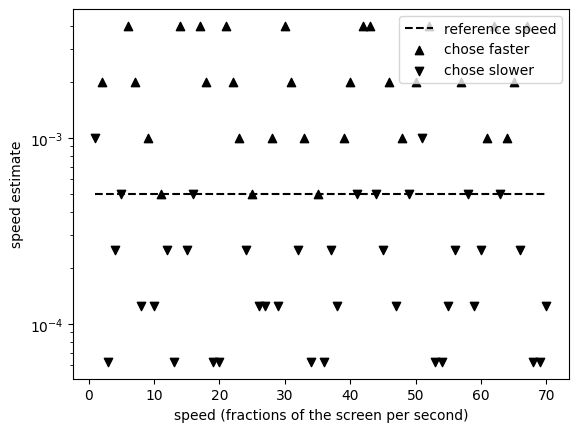

In [46]:
fig, ax = plt.subplots()
trials = np.arange(1, len(stim_speed) + 1)
ax.plot(trials, discrim_data["speed1"].abs(), 'k--')
ax.scatter(trials[response], stim_abs_speed[response], marker='^', color='k')
ax.scatter(trials[~response], stim_abs_speed[~response], marker='v', color='k')
ax.set_yscale('log')
ax.set_xlabel('speed (fractions of the screen per second)')
ax.set_ylabel('speed estimate')
ax.legend(['reference speed', 'chose faster', 'chose slower'])
plt.show()


#### Determine probability of reporting positive difference per condition

Compute performance for each test speed (each comparison level) by calculating the probabaility of reporting that the test speed was greater than the reference speed.


In [47]:
discrim_trials = pd.DataFrame({"speed": stim_abs_speed, "response": response})
discrim_results = (
    discrim_trials
    .groupby("speed", as_index=False)
    .agg(n_trials=("response", "size"), mean_response=("response", "mean"))
)
display(discrim_results)


,speed,n_trials,mean_response
0,0.000063,10,0.0
1,0.000125,10,0.0
2,0.000250,10,0.0
3,0.000500,10,0.3
4,0.001000,10,0.8
5,0.002000,10,1.0
6,0.004000,10,1.0


#### Fit a psychometric curve to the data


In [48]:
# fit psychometric curve to data using psignifit
discrim_psignifit_data = np.column_stack([
    np.log(discrim_results["speed"].to_numpy(dtype=float)),
    discrim_results["mean_response"].to_numpy(dtype=float) * discrim_results["n_trials"].to_numpy(dtype=float),
    discrim_results["n_trials"].to_numpy(dtype=float),
])
discrim_psignifit_result = fit_psignifit(discrim_psignifit_data, experiment_type="yes/no")
discrim_params = psignifit_parameter_array(discrim_psignifit_result, fallback_gamma=0.0, fallback_lambda=0.0)
discrim_param_table = display_fit_table(discrim_params)
display(discrim_param_table)


,fit
mu,-7.320065e+00
sigma,4.279357e-01
gamma,3.291119e-09
lambda,1.919921e-08


#### Plot the data and the psychometric curve


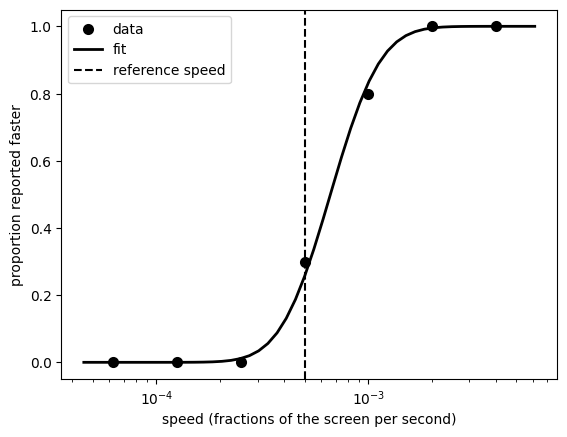

In [49]:
# calculate curves from fits
xx = np.arange(-10, -5, 0.1)
yy = psignifit_predict(discrim_psignifit_result, xx, discrim_params)

# plot the data and the fits
fig, ax = plt.subplots()
ax.scatter(discrim_results["speed"], discrim_results["mean_response"], color='k', linewidth=2, label='data')
ax.plot(np.exp(xx), yy, 'k-', linewidth=2, label='fit')
ax.axvline(discrim_data["speed1"].abs().mean(), color='k', linestyle='--', label='reference speed')
ax.set_xscale('log')
ax.set_xlabel('speed (fractions of the screen per second)')
ax.set_ylabel('proportion reported faster')
ax.legend()
plt.show()


#### Compute and plot the PSE and JND

In Lab 5, you calculated two metrics from the psychometric curve that you fit to your data. One was the **point of subjective equality (PSE)**, which tells us about the level of bias in your response, and the other was the **just noticeable difference (JND)**, which tells us something about how precisely you can distinguish between different stimulus levels.

Let's calculate those values for this experiment, and then let's visualize them.


,PSE,true reference speed
0,0.000662,0.0005


0.3025962108204528


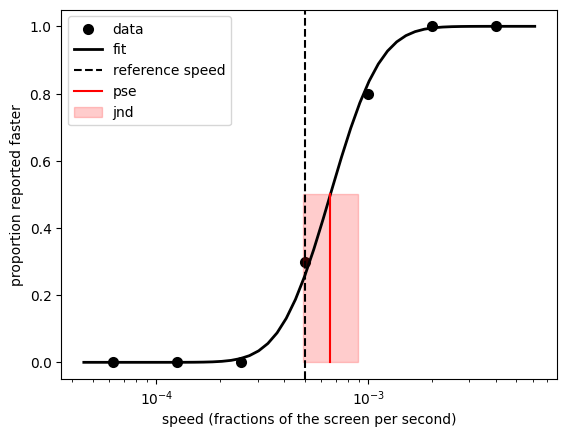

In [64]:
# calculate PSE
pse = float(np.exp(ipsyfxn(discrim_params, 0.5)))
discrim_param_table = pd.DataFrame({
    "PSE": [pse],
    "true reference speed": [discrim_data["speed1"].abs().mean()],
})
display(discrim_param_table)

# calculate JND
jnd = float(discrim_params[1] / np.sqrt(2))  # this is in log speed units
print(jnd)

# plot the PSE +/- JND along with the data and fitted curve
fig, ax = plt.subplots()
ax.scatter(discrim_results["speed"], discrim_results["mean_response"], color='k', linewidth=2, label='data')
ax.plot(np.exp(xx), yy, 'k-', linewidth=2, label='fit')
ax.axvline(discrim_data["speed1"].abs().mean(), color='k', linestyle='--', label='reference speed')
ax.plot([pse, pse], [0, 0.5], 'r-', linewidth=1.5, label='pse')
jnd_x = np.array([np.exp(np.log(pse) - jnd), np.exp(np.log(pse) + jnd), np.exp(np.log(pse) + jnd), np.exp(np.log(pse) - jnd)])
jnd_y = np.array([0, 0, 0.5, 0.5])
ax.fill(jnd_x, jnd_y, color='r', alpha=0.2, label='jnd')
ax.set_xscale('log')
ax.set_xlabel('speed (fractions of the screen per second)')
ax.set_ylabel('proportion reported faster')
ax.legend()
plt.show()


**What do you notice?** What do you think about your results?

## Part B.  Speed Estimation Experiment

### Step 1. Data collection

To collect data, open the PsychoPy ".psyexp" file in the folder titled "speed-estimation", and run that experiment. The instructions will appear on the screen before the trials begin. A single run of the experiment includes 70 trials.

### Step 2. Load your data

#### Find files for specific participant ID

Before running this section of code, enter the participant ID you used below.


In [51]:
participant_id = "demo"

# check current working directory and find files
estim_file_info = find_participant_files(Path("speed-estimation") / "data", participant_id)
n_files = len(estim_file_info)


data files found:
    "demo_speed-estimation_2025-02-14_18h51.09.433.csv"


**Confirm that all of your data files are listed above.** There should be one file.

#### Load and merge data tables


In [52]:
# load data and stack it into one table
estim_data = load_psychopy_csvs(estim_file_info)

# display data table size
n_trials = len(estim_data)
print(f"number of trials = {n_trials}")


number of trials = 35


### Step 3. Analyze your data

For this experiment, the stimulus was a random dot kinematogram. Half of the trials showed motion to the left, and half showed motion to the right. The speed of the stimulus varied, and you were asked to report your estimate of the stimulus's speed using a slider.

For each trial, PsychoPy saved the stimulus speed and your response.


In [53]:
# stash the stimulus speed and estimation data
stim_speed = estim_data["speed"].astype(float)
estimated_speed = estim_data["slider.response"].astype(float).fillna(2)


#### Visualize the response per trial


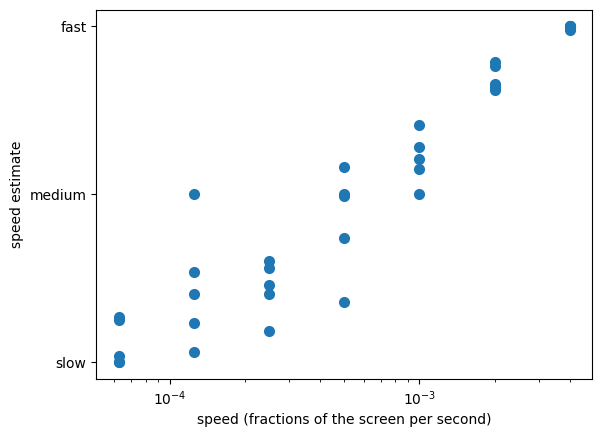

In [54]:
fig, ax = plt.subplots()
ax.scatter(stim_speed, estimated_speed, linewidth=2)
ax.set_xscale('log')
ax.set_yticks([1, 2, 3], labels=['slow', 'medium', 'fast'])
ax.set_xlabel('speed (fractions of the screen per second)')
ax.set_ylabel('speed estimate')
plt.show()


#### Determine average rating per test speed


In [55]:
estim_trials = pd.DataFrame({"speed": stim_speed, "estimate": estimated_speed})
estim_results = (
    estim_trials
    .groupby("speed", as_index=False)
    .agg(n_trials=("estimate", "size"), mean_estimate=("estimate", "mean"), std_estimate=("estimate", "std"))
)
display(estim_results)


,speed,n_trials,mean_estimate,std_estimate
0,0.000063,5,1.112729,0.138167
1,0.000125,5,1.447556,0.357165
2,0.000250,5,1.443483,0.163920
3,0.000500,5,1.849796,0.313064
4,0.001000,5,2.210794,0.152690
5,0.002000,5,2.695519,0.076701
6,0.004000,5,2.994603,0.008653


#### Plot average rating as a function of test speed


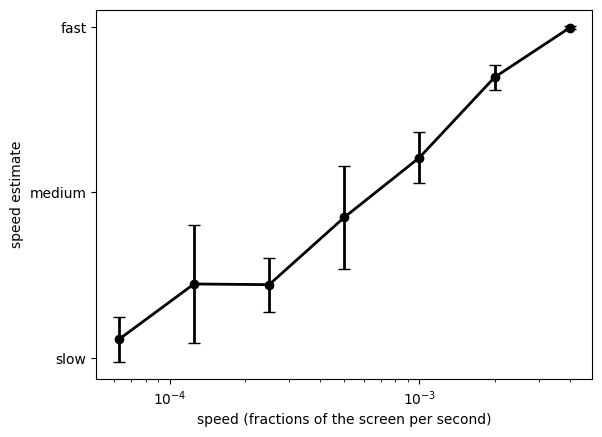

In [56]:
fig, ax = plt.subplots()

estim_results_sorted = estim_results.sort_values("speed")

ax.errorbar(
    estim_results_sorted["speed"],
    estim_results_sorted["mean_estimate"],
    yerr=estim_results_sorted["std_estimate"],
    fmt='o-',          
    color='k',
    linewidth=2,
    capsize=4
)

ax.set_xscale('log')
ax.set_yticks([1, 2, 3], labels=['slow', 'medium', 'fast'])
ax.set_xlabel('speed (fractions of the screen per second)')
ax.set_ylabel('speed estimate')

plt.show()

**What do you notice?** What do you think about your results?
